# LLM Fake News Classifier

This notebook is one part of the Calibrating Truth project which focuses on detecting misinformation in online news articles using BERT and LLM. In the current information economy, fake news is very easily produced and difficult to verify manually. Because of this, it is very important to have an automated fake news detection for supporting more reliable information systems. While the other half of the project utilized BERT, this notebook uses LLMs and the RAGAS (Retrieval Augmented Generation Assessment) libraby. The main goal of this notebook is to build an LLM classification pipeline using the ISOT fake and real news dataset where each article is labelled as either Fake or Real. The notebook follows the following workflow: loading the dataset, cleaning and preparing the text, defining the evaluation criteria (LLM instructions), classifying each article with an LLM (ChatGPT), scoring that output with RAGAS (also through ChatGPT), judging the verdict with a second LLM (Gemini), and finally evaluating performance against the ground-truth labels of the articles.

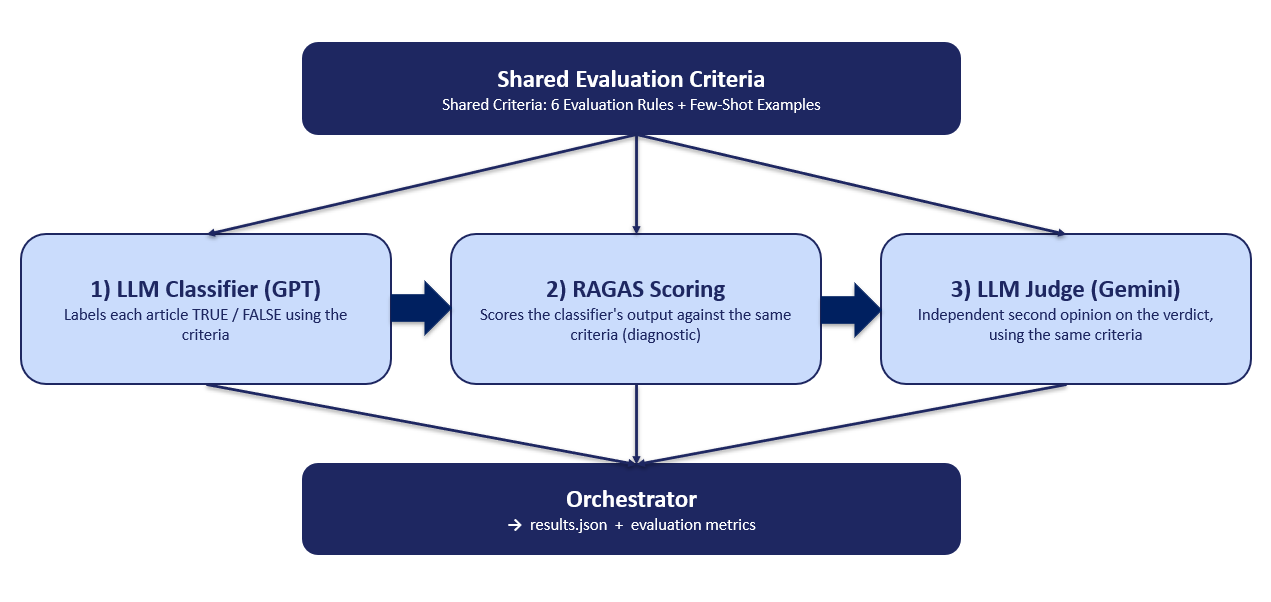

An article is evaluated in three stages:

The initial LLM classifier labels each article TRUE or FALSE (misinformation). RAGAS then scores how well that decision is founded accourding to its criteria (five metrics), and a second LMM judge independently re-checks the conclusion using the same criteria.

Label convention: **TRUE = reliable (Real, 1), FALSE = misinformation (Fake, 0)** —
matching the BERT half of the project so the two systems are directly comparable.

The final evaluation is done in two parts:

| Section | Content |
|---------|---------|
| **A** | Objective Classification: Accuracy, Precision, Recall, F1, Confusion Matrix |
| **B** | LLM diagnostics: RAGAS scores + LLM-as-a-Judge agreement |

> **Shareable:** Works in Google Colab (GPU recommended) and local Jupyter.  
> Set your `OPENAI_API_KEY` and `GEMINI_API_KEY` in the `Config` class (or as variables) or set mock mode to run wihtout API calls (set `PIPELINE_MOCK` to 1)


## Step 0: Install Dependencies

The first step is installing all required python libraries used throughout the training pipeline.


1.   OpenAI: used to call the GPT-4o mini classifier and, through its OpenAI-compatible endpoint, the Gemini judge
2.   RAGAS: metrics to score first classifier's output
3.   LangChain: enables RAGAS to connect to the OpenAI models
4.   Scikit-learn, matplotlib, and seaborn: used to compute and visualise the objective classification metrics
5.   pandas and datasets: and preparing the article data



In [31]:
# one-time install of all dependencies
!pip install -q openai ragas==0.2.14 "langchain<0.4" "langchain-core<0.4" "langchain-community<0.4" "langchain-openai<0.4" datasets pandas scikit-learn matplotlib seaborn



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1: Configuration

This step imports the libraries needed for data processing, evaluation, and visualisation. It also defines the main configuration settings in one place, including the API keys, model names, file paths, the number of articles to evaluate, and the random seed. The main purpose of this configuration, especially the random seed, is to make the pipeline reproducible.
The classifier is set to gpt-4o-mini because it is fast and inexpensive while still able to follow the evaluation criteria, and the judge is set to gemini-2.5-flash-lite, which runs independently. Temperatures are set to 0 for more reproducible results. `N_TEST` is set to 150 to keep each run in terms of time/API costs, and `RAGAS_SAMPLE` limits the slow RAGAS stage to the first 30 articles. The random seed is fixed at 42 to make the sampling reproducible. The `MOCK` option (0 be default, can be enabled by setting to 0) allows the notebook to run the full pipeline without any API calls for quick testing.


In [ ]:
import os, json, csv, random, re   # stdlib helpers
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
%matplotlib inline

class Config:                        # all settings in one place
    # --- API keys (or set env vars of the same name) ---
    OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "xxx")   # classifier + RAGAS
    JUDGE_API_KEY  = os.getenv("GEMINI_API_KEY", "xxx")  # Gemini judge (AI Studio)

    # --- Models ---
    CLASSIFIER_MODEL      = "gpt-4o-mini"             # Stage 1
    RAGAS_LLM_MODEL       = "gpt-4o-mini"             # Stage 2 grader
    RAGAS_EMBEDDING_MODEL = "text-embedding-3-small"  # Stage 2 embeddings
    JUDGE_MODEL           = "gemini-2.5-flash-lite"   # Stage 3 (free tier: 1,000 req/day)
    JUDGE_BASE_URL        = "https://generativelanguage.googleapis.com/v1beta/openai/"  # Gemini OpenAI-compatible

    # --- Generation ---
    CLASSIFIER_TEMPERATURE = 0.0     # deterministic
    JUDGE_TEMPERATURE      = 0.0     # deterministic

    # --- Paths / run size ---
    DATA_FILE    = "data/articles.csv"     # input CSV
    RESULTS_FILE = "results/results.json"  # output
    N_TEST       = 200   # articles per run (classifier + judge on all of these)
    RAGAS_SAMPLE = 40   # run slow RAGAS on only the first N articles
    MOCK         = os.getenv("PIPELINE_MOCK", "0") == "1"  # True = no API calls

RANDOM_STATE = 42   # fixed seed -> reproducible sampling


## Step 2: Evaluation criteria (single source of truth)

We define 6 criteria as part of the LMMs' instruction what makes each article more reliable or unreliable, and we use the few-shots technique to give the LLMs outcome examples. 
They are defined once and fed into the classifier prompt, RAGAS, and the judge prompt, thus each use the same rulebook. LLM here also aided in brainstorming and refinig the instruction wording, informed by the literature, which includes:

- Cavazos, R., & CHEQ. (2019). The economic cost of bad actors on the internet: Fake news 2019. CHEQ & University of Baltimore.
- Gruensteidl, M. N. & Kirrane, S. (2026). An Evaluation of XAI Methods applied to Information Disorder Detection Models. Knowledge-Based Systems 336 (2026) 115305. 
- Kaliyar, R. K., Goswami, A., & Narang, P. (2021). FakeBERT: Fake news detection in social media with a BERT-based deep learning approach. Multimedia Tools and Applications, 80(8), 11765–11788. https://doi.org/10.1007/s11042-020-10183-2
- Newman, N., Fletcher, R., Robertson, C. T., Ross Arguedas, A., & Nielsen, R. K. (2024). Reuters Institute digital news report 2024. Reuters Institute for the Study of Journalism.
- Raza, S., Paulen-Patterson, D., & Ding, C. (2024). Fake news detection: Comparative evaluation of BERT-like models and large language models with generative AI-annotated data (Preprint). arXiv. https://arxiv.org/abs/2412.14276
- Shu, K., Mahudeswaran, D., Wang, S., Lee, D., & Liu, H. (2020). FakeNewsNet: A data repository with news content, social context, and spatiotemporal information for studying fake news on social media. Big Data, 8(3), 171–188. https://doi.org/10.1089/big.2020.0062
- Sopra Steria. (2026). Disinformation's global economic impact estimated at $417 billion in Sopra Steria study [Press release]. https://www.soprasteria.com/newsroom/press-releases/details/disinformation-s-global-economic-impact-estimated-at-417-billion-in-sopra-steria-study
- Thorne, J., Vlachos, A., Christodoulopoulos, C., & Mittal, A. (2018). FEVER: A large-scale dataset for fact extraction and VERification. Proceedings of the 2018 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies (pp. 809–819). Association for Computational Linguistics. https://doi.org/10.18653/v1/N18-1074
- Verma, P. K., Agrawal, P., Amorim, I., & Prodan, R. (2021). WELFake: Word embedding over linguistic features for fake news detection. IEEE Transactions on Computational Social Systems, 8(4), 881–893. https://doi.org/10.1109/TCSS.2021.3068519
- Vosoughi, S., Roy, D., & Aral, S. (2018). The spread of true and false news online. Science, 359(6380), 1146–1151. https://doi.org/10.1126/science.aap9559
- Wang, W. Y. (2017). “Liar, liar pants on fire”: A new benchmark dataset for fake news detection. Proceedings of the 55th Annual Meeting of the Association for Computational Linguistics (Vol. 2: Short Papers) (pp. 422–426). Association for Computational Linguistics. https://doi.org/10.18653/v1/P17-2067

In [33]:
CRITERIA = [                         # 6 rules: C1-C3,C5 raise suspicion; C4,C6 lower it
    {"id": "C1", "name": "Unverifiable sources",
     "rule": "If the article makes factual claims without naming a verifiable source (no named officials, institutions, studies, or documents), it is MORE likely to be misinformation."},
    {"id": "C2", "name": "Emotional / sensational language",
     "rule": "If the article relies on highly emotional, alarmist, or sensational language (e.g. 'SHOCKING', 'they don't want you to know'), it is MORE likely to be misinformation."},
    {"id": "C3", "name": "Internal consistency",
     "rule": "If the article contradicts itself (dates, numbers, or claims that conflict within the text), it is MORE likely to be misinformation."},
    {"id": "C4", "name": "Attribution to named, checkable entities",
     "rule": "If claims are attributed to named, checkable entities (specific agencies, journals, on-record individuals), it is LESS likely to be misinformation."},
    {"id": "C5", "name": "Implausible causal claims",
     "rule": "If the article asserts extraordinary causal claims that contradict well-established scientific consensus without extraordinary evidence, it is MORE likely to be misinformation."},
    {"id": "C6", "name": "Balanced presentation",
     "rule": "If the article presents multiple perspectives, acknowledges uncertainty, or includes responses from involved parties, it is LESS likely to be misinformation."},
]

FEW_SHOT_EXAMPLES = [                 # 6 labelled examples (3 TRUE / 3 FALSE) shown to the model
    {"article": "BREAKING: Scientists CONFIRM drinking lemon water cures cancer in 48 hours! Doctors are furious - the truth THEY hide from you. Share before this gets deleted!",
     "label": "FALSE",
     "reasoning": "Triggers C1 (no named source), C2 (sensational language, urgency), C5 (extraordinary medical claim contradicting consensus). No criterion lowering suspicion applies."},
    {"article": "The Federal Reserve raised its benchmark interest rate by 0.25 percentage points on Wednesday, Chair Jerome Powell announced, citing persistent inflation. Some economists, including Mark Zandi of Moody's Analytics, argued the move was premature.",
     "label": "TRUE",
     "reasoning": "Triggers C4 (named, checkable entities: Federal Reserve, Powell, Zandi/Moody's) and C6 (includes dissenting expert view). No misinformation signals (C1, C2, C3, C5) present."},
    {"article": "A new report claims 90% of the city's water supply is contaminated, although the same report later states only 12% of samples failed testing. Officials could not be reached.",
     "label": "FALSE",
     "reasoning": "Triggers C3 (internal contradiction: 90% vs 12%) and C1 (no verifiable source for the headline claim)."},
    {"article": "The World Health Organization reported on Monday that global measles cases rose 18% in 2023, drawing on surveillance data compiled with the U.S. Centers for Disease Control. WHO officials cautioned that reporting gaps in several regions may affect the estimate.",
     "label": "TRUE",
     "reasoning": "Triggers C4 (named, checkable entities: WHO, U.S. CDC) and C6 (acknowledges uncertainty in the data). No misinformation signals (C1, C2, C3, C5) present."},
    {"article": "A study published in The Lancet by researchers at the University of Oxford found that moderate exercise was associated with lower blood pressure in older adults. The authors noted the observational design cannot establish causation.",
     "label": "TRUE",
     "reasoning": "Triggers C4 (named journal and institution: The Lancet, University of Oxford) and C6 (explicitly acknowledges a methodological limitation). No misinformation signals present."},
    {"article": "URGENT: 5G towers are SECRETLY rewiring your brain, a viral video warns. The clip cites no studies and names no experts, but insists millions are already affected and that the media is hiding the truth.",
     "label": "FALSE",
     "reasoning": "Triggers C1 (no named source or study), C2 (sensational, urgent 'they're hiding it' framing), and C5 (extraordinary causal claim contradicting scientific consensus without evidence)."},
]

TASK_INSTRUCTION = (                  # shared task description for every stage
    "You are a news verification system. Evaluate whether the news article is TRUE "
    "(reliable) or FALSE (misinformation) using ONLY the evaluation criteria provided. "
    "For each criterion, state whether it applies. Then give a final verdict."
)

def criteria_block():                 # criteria as plain text
    return "\n".join(f"[{c['id']}] {c['name']}: {c['rule']}" for c in CRITERIA)

def few_shot_block():                 # examples as plain text
    parts = []
    for i, ex in enumerate(FEW_SHOT_EXAMPLES, 1):
        parts.append(f"Example {i}:\nArticle: {ex['article']}\nVerdict: {ex['label']}\nReasoning: {ex['reasoning']}")
    return "\n\n".join(parts)

def build_classifier_system_prompt():   # Stage 1 system prompt (task + criteria + examples + JSON spec)
    return (
        f"{TASK_INSTRUCTION}\n\n"
        f"EVALUATION CRITERIA:\n{criteria_block()}\n\n"
        f"EXAMPLES:\n{few_shot_block()}\n\n"
        "Respond in strict JSON with keys: "
        '{"label": "TRUE" | "FALSE", "confidence": 0.0-1.0, '
        '"criteria_triggered": ["C1", ...], "reasoning": "<2-4 sentences citing criteria ids>"}'
    )

def criteria_as_contexts():             # same criteria + examples, chunked as RAGAS contexts
    chunks = [f"[{c['id']}] {c['name']}: {c['rule']}" for c in CRITERIA]
    chunks.append(f"Task: {TASK_INSTRUCTION}")
    chunks += [f"Example - Article: {ex['article']} Verdict: {ex['label']} Reasoning: {ex['reasoning']}"
               for ex in FEW_SHOT_EXAMPLES]
    return chunks

def build_judge_system_prompt():        # Stage 3 system prompt (judge the verdict against same criteria)
    return (
        "You are an impartial judge. Another model classified a news article as TRUE "
        "(reliable) or FALSE (misinformation). Judge whether its verdict and reasoning "
        "correctly apply the evaluation criteria below - the SAME criteria the model "
        "was given.\n\n"
        f"EVALUATION CRITERIA:\n{criteria_block()}\n\n"
        "Respond in strict JSON with keys: "
        '{"agree": true | false, "judge_label": "TRUE" | "FALSE", '
        '"criteria_application_score": 0.0-1.0, '
        '"critique": "<2-4 sentences: which criteria were applied correctly/incorrectly or missed>"}'
    )


## Step 3: Stage 1, Classifier (GPT-4o mini)

The classifier receives a news article plus the shared instructions defined in the previous step, and returns
a verdits in JSON form: a TRUE/FALSE label, a confidence, the criteria it triggered (listed above), and a short reasoning. `MOCK` mode returns a fixed response so the
whole pipeline can be tested without API calls, but the output is not meaningful.


In [34]:
def _parse_json(text):                # tolerant JSON parse (strips ```json fences)
    text = text.strip()
    if text.startswith("```"):
        text = text.split("```")[1]
        text = text.removeprefix("json").strip()
    return json.loads(text)

def classify_article(article_text):   # Stage 1: GPT-4o mini -> TRUE/FALSE verdict
    if Config.MOCK:                   # mock: fixed reply, no API call
        return {"label": "FALSE", "confidence": 0.9, "criteria_triggered": ["C1", "C2"],
                "reasoning": "MOCK: article lacks verifiable sources (C1) and uses sensational language (C2)."}
    client = OpenAI(api_key=Config.OPENAI_API_KEY)
    resp = client.chat.completions.create(           # call OpenAI, force JSON output
        model=Config.CLASSIFIER_MODEL,
        temperature=Config.CLASSIFIER_TEMPERATURE,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": build_classifier_system_prompt()},
            {"role": "user", "content": f"Evaluate this news article:\n\n{article_text}"},
        ],
    )
    out = _parse_json(resp.choices[0].message.content)
    out["label"] = str(out.get("label", "")).upper()  # normalize -> "TRUE"/"FALSE"
    out.setdefault("criteria_triggered", [])          # fill missing keys
    out.setdefault("confidence", None)
    out.setdefault("reasoning", "")
    return out


## Step 4: Stage 2, RAGAS scoring

RAGAS (RAG Assessment) scores the quality of the classifier's answer using five criteria. The
retrieved contexts given to RAGAS match the criteria used by the first LMM classifier,
plus the same article , thus the metrics measure whether the reasoning is
grounded in those instructions and whether the verdict matches the ground truth:
faithfulness, answer relevancy, context precision, context recall, and answer
correctness, which are stnadard RAGAS measures.


In [35]:
def _ragas_reference_text(ground_truth_label):       # gold answer text from the label
    verdict = "FALSE (misinformation)" if ground_truth_label.upper() == "FALSE" else "TRUE (reliable)"
    return f"According to the evaluation criteria, this article should be classified as {verdict}."

def _ragas_response_text(classifier_output):         # classifier output as one string
    return (f"Verdict: {classifier_output['label']}. "
            f"Criteria triggered: {', '.join(classifier_output.get('criteria_triggered', [])) or 'none'}. "
            f"Reasoning: {classifier_output.get('reasoning', '')}")

def score_with_ragas(article_text, classifier_output, ground_truth_label):  # Stage 2: 5 RAGAS scores
    if Config.MOCK:                   # mock: fixed scores, no API call
        return {"faithfulness": 0.9, "answer_relevancy": 0.88, "context_precision": 0.8,
                "context_recall": 0.75, "answer_correctness": 1.0}
    from langchain_openai import ChatOpenAI, OpenAIEmbeddings
    from ragas.embeddings import LangchainEmbeddingsWrapper
    from ragas.llms import LangchainLLMWrapper
    from ragas import EvaluationDataset, evaluate
    from ragas.dataset_schema import SingleTurnSample
    from ragas.metrics import (AnswerCorrectness, Faithfulness,
                               LLMContextPrecisionWithReference, LLMContextRecall, ResponseRelevancy)

    llm = LangchainLLMWrapper(ChatOpenAI(model=Config.RAGAS_LLM_MODEL, api_key=Config.OPENAI_API_KEY, temperature=0))   # grader LLM
    emb = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model=Config.RAGAS_EMBEDDING_MODEL, api_key=Config.OPENAI_API_KEY))  # embeddings

    sample = SingleTurnSample(        # one record: question / contexts / answer / reference
        user_input=f"{TASK_INSTRUCTION}\n\nArticle:\n{article_text}",
        retrieved_contexts=criteria_as_contexts() + [f"ARTICLE UNDER EVALUATION:\n{article_text}"],  # criteria + article
        response=_ragas_response_text(classifier_output),
        reference=_ragas_reference_text(ground_truth_label),
    )
    metrics = [Faithfulness(llm=llm), ResponseRelevancy(llm=llm, embeddings=emb),   # the 5 metrics
               LLMContextPrecisionWithReference(llm=llm), LLMContextRecall(llm=llm),
               AnswerCorrectness(llm=llm, embeddings=emb)]
    result = evaluate(dataset=EvaluationDataset(samples=[sample]), metrics=metrics)
    df = result.to_pandas(); row = df.iloc[0]

    def pick(*names):                 # column names vary by ragas version -> try each
        for n in names:
            if n in df.columns:
                return float(row[n])
        return None

    return {"faithfulness": pick("faithfulness"),
            "answer_relevancy": pick("answer_relevancy", "response_relevancy"),
            "context_precision": pick("llm_context_precision_with_reference", "context_precision"),
            "context_recall": pick("context_recall", "llm_context_recall"),
            "answer_correctness": pick("answer_correctness")}


## Step 5: Stage 3, LLM-as-Judge (Google Gemini)

We use so-called cross-model (different from the initial ChatGPT) judge which scores one article at a time. Is uses the same cirteria as the previous stages. Temperature is similarly set to 0. It of course does not see the ground-truth label either.

It returns its agreement/disagreement, its own independent label, a 0–1
criteria-application score, and a short textual critique. Because it applies its own label,
the pipeline can report an agreement rate between judge and classifier. 


In [36]:
def judge(article_text, classifier_output):   # Stage 3: Gemini second opinion on the verdict
    if Config.MOCK:                            # mock: agree, no API call
        return {"agree": True, "judge_label": classifier_output["label"],
                "criteria_application_score": 0.85,
                "critique": "MOCK: criteria C1/C2 applied correctly; C5 was not considered."}
    client = OpenAI(api_key=Config.JUDGE_API_KEY, base_url=Config.JUDGE_BASE_URL)  # Gemini via OpenAI client
    user_msg = f"ARTICLE:\n{article_text}\n\nCLASSIFIER OUTPUT:\n{json.dumps(classifier_output, indent=2)}"
    try:
        resp = client.chat.completions.create(  # ask Gemini to judge
            model=Config.JUDGE_MODEL,
            temperature=Config.JUDGE_TEMPERATURE,
            messages=[{"role": "system", "content": build_judge_system_prompt()},
                      {"role": "user", "content": user_msg}],
        )
        out = _parse_json(resp.choices[0].message.content)
        out["judge_label"] = str(out.get("judge_label", "")).upper()  # normalize label
        return out
    except Exception as e:                       # safety-filter / API error -> record, don't crash
        return {"agree": None, "judge_label": None, "criteria_application_score": None,
                "critique": None, "judge_error": str(e)}


## Step 6: Data preprocessing (ISOT dataset)

This step prepares the raw news data before evaluation similar to the BERT notebook. It loads the ISOT `True.csv` / `Fake.csv` files, removes duplicates and null rows,
strips URLs and emojis, labels reliable news TRUE and misinformation FALSE,
merges the title and body into one `article_text` field, and shuffles. The
cleaning steps mirror the BERT half so both systems see identically cleaned
text. The word cap controls per-article token cost. Run this once to produce
`data/articles.csv`.


In [37]:
def remove_urls(text):                # strip http/https links
    return re.sub(r"(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b", "", str(text), flags=re.MULTILINE)

def remove_emojis(text):              # strip emoji characters
    pattern = re.compile("[" "\U0001F600-\U0001F64F" "\U0001F300-\U0001F5FF"
                         "\U0001F680-\U0001F6FF" "\U0001F1E0-\U0001F1FF" "]+", flags=re.UNICODE)
    return re.sub(pattern, "", str(text))

def _clean_series(s):                 # clean a whole column: urls -> emojis -> trim
    return s.fillna("").astype(str).apply(remove_urls).apply(remove_emojis).str.strip()

def build_articles_csv(true_path="data/True.csv", fake_path="data/Fake.csv",
                       out_path="data/articles.csv", max_words=400):   # ISOT -> pipeline CSV
    true_news = pd.read_csv(true_path).drop_duplicates().dropna(how="all")   # load + dedup
    fake_news = pd.read_csv(fake_path).drop_duplicates().dropna(how="all")
    true_news["label"] = 1            # reliable / Real
    fake_news["label"] = 0            # misinformation / Fake
    df = pd.concat([true_news, fake_news], ignore_index=True)   # combine
    if "title" not in df.columns:
        df["title"] = ""
    df["title"] = _clean_series(df["title"])   # clean title + body
    df["text"] = _clean_series(df["text"])
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)   # shuffle

    article = (df["title"].str.strip() + "\n\n" + df["text"].str.strip()).str.strip()   # merge title+body
    if max_words:
        article = article.apply(lambda t: " ".join(t.split()[:max_words]))   # cap length
    out = pd.DataFrame({"article_text": article,
                        "ground_truth": df["label"].map({1: "TRUE", 0: "FALSE"})})   # 1->TRUE, 0->FALSE
    out = out[out["article_text"].str.strip().astype(bool)].reset_index(drop=True)   # drop empties
    out.insert(0, "id", range(1, len(out) + 1))   # sequential id
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    out.to_csv(out_path, index=False)
    print(f"Wrote {len(out)} articles -> {out_path}  |  balance: {out['ground_truth'].value_counts().to_dict()}")
    return out

build_articles_csv()


Wrote 44689 articles -> data/articles.csv  |  balance: {'FALSE': 23478, 'TRUE': 21211}


,id,article_text,ground_truth
0,1,"Merkel, Juncker discuss Catalan crisis: EU off...",TRUE
1,2,LIBERAL HACK KATIE COURIC Says Fake News Is “T...,FALSE
2,3,TRUMP WAS RIGHT! Audit Reveals State Dept. Cyb...,FALSE
3,4,Clay Aiken Says He Was A ‘F*****g Dumbass’ For...,FALSE
4,5,U.S. militia girds for trouble as presidential...,TRUE
...,...,...,...
44684,44685,Germany's Schaeuble warns Trump over protectio...,TRUE
44685,44686,"Twenty-eight arrests after Venezuela looting, ...",TRUE
44686,44687,HOW THE FBI Cracked A Terror Plot On Black Fri...,FALSE
44687,44688,U.S. tax plan threatens Wall Street's Bermuda ...,TRUE


## Step 7: Orchestration

Each article flows through classifier -> RAGAS (where RAGAS was used) -> judge. Stage 1 is required; Stages 2
and 3 run  independently so a failure in one never discards the others.
RAGAS is optional per article (see `run_ragas`), so the slow stage can be
limited to a sample. `stratified_limit` selects `N_TEST` articles while
preserving the TRUE/FALSE balance, and `summarize` reports the headline numbers.


In [38]:
def load_articles(path):              # read CSV rows as dicts
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

def stratified_limit(articles, n):    # take n rows, keep TRUE/FALSE balance
    if n is None or len(articles) <= n:
        return articles
    rng = random.Random(RANDOM_STATE)
    by_label = {}                     # bucket rows by label
    for a in articles:
        by_label.setdefault(a["ground_truth"].strip().upper(), []).append(a)
    picked = []
    for label, rows in by_label.items():
        k = round(n * len(rows) / len(articles))   # proportional share
        picked += rng.sample(rows, min(k, len(rows)))
    rng.shuffle(picked)
    return picked[:n]

def run_one(article, run_ragas=True):   # run the 3 stages on one article
    text = article["article_text"]
    gt = article["ground_truth"].strip().upper()   # TRUE=reliable, FALSE=misinfo
    verdict = classify_article(text)               # Stage 1 (required)
    if run_ragas:                                  # Stage 2 (optional; slow)
        try:
            ragas_scores = score_with_ragas(text, verdict, gt)
        except Exception as e:
            ragas_scores = {"ragas_error": str(e)}
    else:
        ragas_scores = {}                          # skipped -> ignored by summarize
    judgement = judge(text, verdict)               # Stage 3 (independent)
    return {"id": article.get("id"), "ground_truth": gt, "classifier": verdict,
            "ragas": ragas_scores, "judge": judgement,
            "classifier_correct": verdict["label"] == gt,                 # vs ground truth
            "judge_agrees_with_classifier": judgement.get("agree")}       # judge vs classifier

def summarize(results):               # headline numbers over the run
    n = len(results)
    acc = sum(r["classifier_correct"] for r in results) / n if n else 0   # accuracy
    judged = [r for r in results if r["judge_agrees_with_classifier"] is not None]   # judged only
    agree = sum(r["judge_agrees_with_classifier"] for r in judged) / len(judged) if judged else None
    metric_means = {}                 # RAGAS means (over articles that have them)
    for m in ("faithfulness", "answer_relevancy", "context_precision", "context_recall", "answer_correctness"):
        vals = [r["ragas"][m] for r in results if r["ragas"].get(m) is not None]
        metric_means[m] = round(sum(vals) / len(vals), 3) if vals else None
    return {"n_articles": n, "classifier_accuracy_vs_ground_truth": round(acc, 3),
            "n_judged": len(judged),
            "judge_agreement_rate": round(agree, 3) if agree is not None else None,
            "ragas_mean_scores": metric_means}


## Step 8: Run the pipeline (evaluates N_TEST = 200 articles)

We Loads the dataset, selects a stratified sample of `N_TEST` (= 200) articles, and
runs all three stages on each — except RAGAS, which is the most resource-intensive stage and runs only on the first
`RAGAS_SAMPLE` (= 40) to keep to a reasonable speed and API request/token consumption. Progress can be tracked as this step runs, including whether RAGAS is included for a given article.

Writes per-article detail to
`results.json` and prints the summary. Set `PIPELINE_MOCK=1` first for a no-API
dry run.


In [ ]:
articles = load_articles(Config.DATA_FILE)            # all rows
articles = stratified_limit(articles, Config.N_TEST)  # -> 200, balanced
print(f"Running pipeline on {len(articles)} articles "
      f"({'MOCK MODE - no API calls' if Config.MOCK else 'live'})\n")

results = []
for i, a in enumerate(articles):                      # i drives the RAGAS limit
    do_ragas = i < Config.RAGAS_SAMPLE                # RAGAS only on first N articles
    stages = "classifying -> RAGAS -> judge" if do_ragas else "classifying -> judge (RAGAS skipped)"
    print(f"  [{i + 1}/{len(articles)}] article {a.get('id')}: {stages} ...")   # overall progress
    try:
        results.append(run_one(a, run_ragas=do_ragas))
    except Exception as e:                            # one bad article doesn't stop the run
        print(f"    ERROR on article {a.get('id')}: {e}")
        results.append({"id": a.get("id"), "error": str(e)})

ok = [r for r in results if "error" not in r]         # drop errored rows
summary = summarize(ok)
os.makedirs(os.path.dirname(Config.RESULTS_FILE), exist_ok=True)
with open(Config.RESULTS_FILE, "w", encoding="utf-8") as f:   # save everything
    json.dump({"summary": summary, "results": results}, f, indent=2)

print("\n===== SUMMARY =====")
print(json.dumps(summary, indent=2))


Running pipeline on 200 articles (live)

  [1/200] article 29152: classifying -> RAGAS -> judge ...


Evaluating: 100%|██████████| 5/5 [00:24<00:00,  4.83s/it]


  [2/200] article 6399: classifying -> RAGAS -> judge ...


Evaluating: 100%|██████████| 5/5 [00:22<00:00,  4.41s/it]


  [3/200] article 13368: classifying -> RAGAS -> judge ...


...

  [39/200] article 41989: classifying -> RAGAS -> judge ...


Evaluating: 100%|██████████| 5/5 [00:19<00:00,  3.84s/it]


  [40/200] article 3635: classifying -> RAGAS -> judge ...


Evaluating: 100%|██████████| 5/5 [00:21<00:00,  4.30s/it]


  [41/200] article 26259: classifying -> judge (RAGAS skipped) ...
  [42/200] article 11135: classifying -> judge (RAGAS skipped) ...
  [43/200] article 13803: classifying -> judge (RAGAS skipped) ...
  [44/200] article 37691: classifying -> judge (RAGAS skipped) ...
  [45/200] article 28278: classifying -> judge (RAGAS skipped) ...
  [46/200] article 26344: classifying -> judge (RAGAS skipped) ...
  [47/200] article 19209: classifying -> judge (RAGAS skipped) ...
  [48/200] article 31158: classifying -> judge (RAGAS skipped) ...
  [49/200] article 14734: classifying -> judge (RAGAS skipped) ...
  [50/200] article 39854: classifying -> judge (RAGAS skipped) ...
  [51/200] article 26277: classifying -> judge (RAGAS skipped) ...
  [52/200] article 36364: classifying -> judge (RAGAS skipped) ...
  [53/200] article 6625: classifying -> judge (RAGAS skipped) ...
  [54/200] article 19443: classifying -> judge (RAGAS skipped) ...
  [55/200] article 8704: classifying -> judge (RAGAS skipped) .

We check for "judge errors" to see if the Gemini API is functioning correctly (there may be capacity issues even if call limits are in order).

In [40]:
errs = [r["judge"].get("judge_error") for r in _results
        if isinstance(r.get("judge"), dict) and r["judge"].get("judge_error")]
print(len(errs), "judge errors")
print(errs[0] if errs else "no judge_error found")

2 judge errors
Error code: 503 - [{'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}]


## Step 9: Evaluation A: Classification metrics for Stage 1

These metrics are computed from the classifier's TRUE/FALSE predictions
versus ground truth, so they do not depend on RAGAS and cover all
evaluated articles. They use the same metrics and confusion-matrix
visualizations as the BERT half (Section A) for a direct comparison: accuracy,
precision, recall, F1, and a confusion matrix. Label convention matches BERT —
Real (reliable) = 1, Fake (misinformation) = 0.

Evaluating 200 classified articles (Real=95, Fake=105)

   Metric  Score
 Accuracy 0.9500
Precision 0.9474
   Recall 0.9474
 F1-Score 0.9474

Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       0.95      0.95      0.95       105
        Real       0.95      0.95      0.95        95

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200

Confusion: TN=100  FP=5  FN=5  TP=90


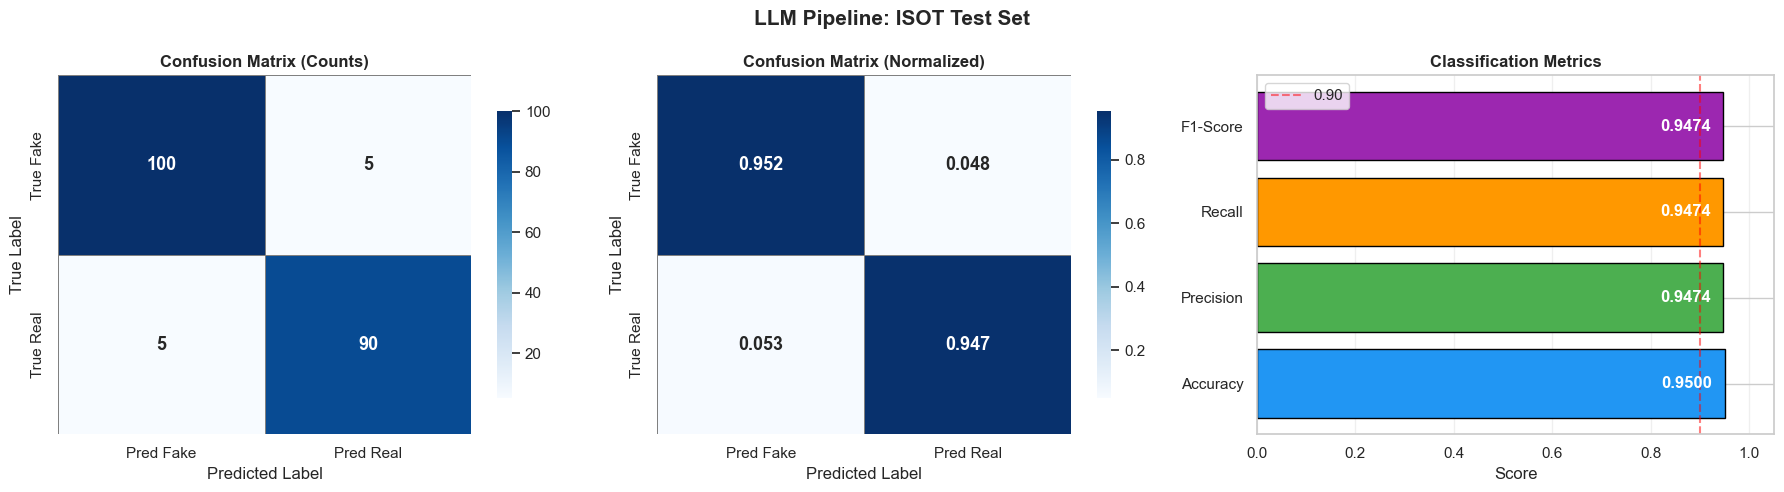

In [41]:
LABEL_TO_INT = {"TRUE": 1, "FALSE": 0}   # Real=1, Fake=0 (same as BERT)

with open(Config.RESULTS_FILE, encoding="utf-8") as f:   # load saved results
    _data = json.load(f)
_results, _summary = _data["results"], _data["summary"]

y_true, y_pred = [], []               # build label arrays from classifier verdicts
for r in _results:
    if "error" in r:                  # skip errored rows
        continue
    gt = r["ground_truth"].strip().upper()
    pred = r["classifier"]["label"].strip().upper()
    if gt in LABEL_TO_INT and pred in LABEL_TO_INT:
        y_true.append(LABEL_TO_INT[gt]); y_pred.append(LABEL_TO_INT[pred])

print(f"Evaluating {len(y_true)} classified articles "
      f"(Real={sum(y_true)}, Fake={len(y_true) - sum(y_true)})")

acc  = accuracy_score(y_true, y_pred)                                  # objective metrics
prec = precision_score(y_true, y_pred, average="binary", zero_division=0)
rec  = recall_score(y_true, y_pred, average="binary", zero_division=0)
f1   = f1_score(y_true, y_pred, average="binary", zero_division=0)
cm   = confusion_matrix(y_true, y_pred, labels=[0, 1])                 # [[TN,FP],[FN,TP]]

metrics_table = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
                              "Score": [acc, prec, rec, f1]})
print(); print(metrics_table.to_string(index=False, float_format="{:.4f}".format)); print()
print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["Fake", "Real"], zero_division=0))
print(f"Confusion: TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))                        # 3 panels
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True).clip(min=1)   # row-normalized
for ax, data, fmt, title in [(axes[0], cm, "d", "Counts"), (axes[1], cm_norm, ".3f", "Normalized")]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", ax=ax,        # confusion-matrix heatmaps
                xticklabels=["Pred Fake", "Pred Real"], yticklabels=["True Fake", "True Real"],
                linewidths=0.5, linecolor="gray", cbar_kws={"shrink": 0.8},
                annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(f"Confusion Matrix ({title})", fontweight="bold")
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
ax = axes[2]                          # metrics bar chart
names, vals = ["Accuracy", "Precision", "Recall", "F1-Score"], [acc, prec, rec, f1]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
bars = ax.barh(names, vals, color=colors, edgecolor="black")
for bar, v in zip(bars, vals):        # value labels
    ax.text(v - 0.025, bar.get_y() + bar.get_height() / 2, f"{v:.4f}",
            va="center", ha="right", fontweight="bold", color="white", fontsize=12)
ax.set_xlim([0, 1.05]); ax.axvline(0.9, color="red", linestyle="--", alpha=0.5, label="0.90")  # 0.90 ref line
ax.set_title("Classification Metrics", fontweight="bold"); ax.set_xlabel("Score"); ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.suptitle("LLM Pipeline: ISOT Test Set", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig("llm_objective_metrics.png", dpi=150, bbox_inches="tight"); plt.show()


## Step 10: Evaluation B: Stage 2 (RAGAS subset) and Stage 3 (larger set)

This second stage's evaluation uses the RAGAS scores, so it covers only the
`RAGAS_SAMPLE` articles that went through RAGAS. It reports the mean RAGAS
scores (reasoning quality).

The "Judge versus Classifier" evaluation covers the larger sample of 200 articles.

These are both LLM-graded diagnostics, and thus have a black box quality, might have bias and are not perfectly objective.

Lastly, while SHAP and LIME were used to evalue the BERT part of this project, this was not done for the LLM pipeline in part due to the limited API resources which they would call on many times, and metrics such as the LLMs' self-reported confidence in their jusgement is not a reliable/stable value to calibrate. The LLMs also already provide reasoning for their judgement, thus SHAP and LIME's analysis of which words lead to certain predictions is not crucial.

Judge agreement rate : 0.673 (over 156 judged)
RAGAS mean scores    : {'faithfulness': 0.776, 'answer_relevancy': 0.395, 'context_precision': 0.553, 'context_recall': 0.525, 'answer_correctness': 0.696}


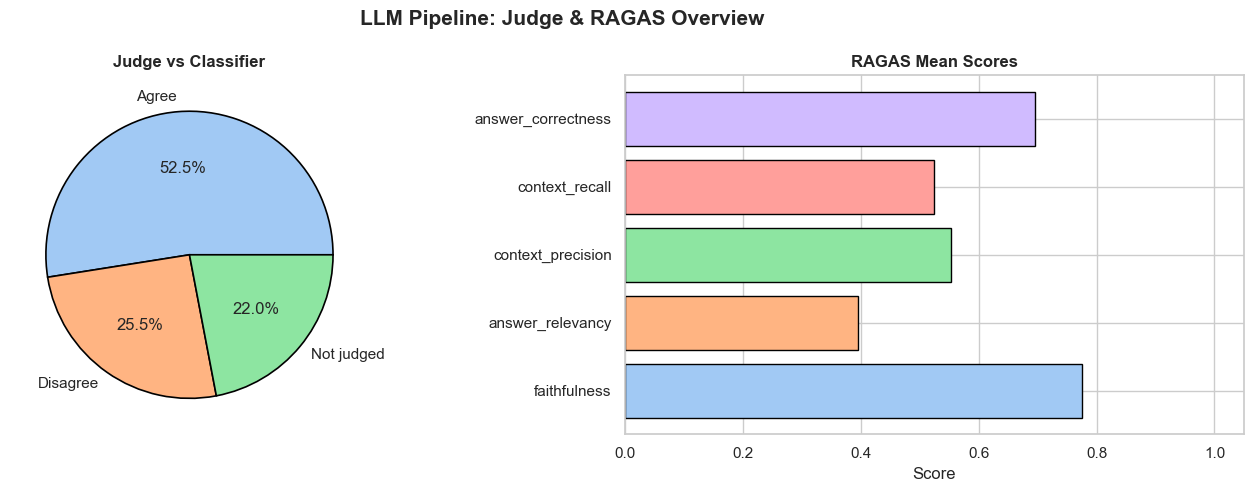

In [ ]:
# Evaluation B: RAGAS-based diagnostic over the RAGAS subset (RAGAS means); judge agreement (Gemini)
judged   = [r for r in _results if r.get("judge_agrees_with_classifier") is not None]   # judged rows
agree    = sum(r["judge_agrees_with_classifier"] for r in judged)
disagree = len(judged) - agree
blocked  = sum(1 for r in _results if "error" not in r and r.get("judge_agrees_with_classifier") is None)  # filtered
print(f"Judge agreement rate : {_summary.get('judge_agreement_rate')} (over {_summary.get('n_judged')} judged)")
print(f"RAGAS mean scores    : {_summary.get('ragas_mean_scores')}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie([agree, disagree, blocked], labels=["Agree", "Disagree", "Not judged"],   # judge breakdown
            autopct=lambda p: f"{p:.1f}%" if p > 0 else "", colors=sns.color_palette("pastel"),
            wedgeprops={"edgecolor": "black", "linewidth": 1.2})
axes[0].set_title("Judge vs Classifier", fontweight="bold")
means = {k: v for k, v in (_summary.get("ragas_mean_scores") or {}).items() if v is not None}   # drop None
if means:
    axes[1].barh(list(means.keys()), list(means.values()), color=sns.color_palette("pastel"), edgecolor="black")
    axes[1].set_xlim([0, 1.05]); axes[1].set_title("RAGAS Mean Scores", fontweight="bold"); axes[1].set_xlabel("Score")
plt.suptitle("LLM Pipeline: Judge & RAGAS Overview", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig("llm_judge_overview.png", dpi=150, bbox_inches="tight"); plt.show()


## Step 11: Interpreting results & iterative refinement

Classifier accuracy versus ground truth is directly comparable to the BERT model (there mertics are ca. 95%, overall high but fall short of the BERT results for now), while RAGAS scores and judge agreement measure reasoning quality and consistency, not necessarity correctness. Findings give us ammunition for iterative refinement of the criteria and LLM incstructions.

- Low faithfulness or correcness could mean reasoning is not grounded in the criteria, thus wording may be tightened
- Low context precision / recall could mean ambigupus criteria are not applied consistently; same implication due to judge disagreement
- low answer relevancy may be an artifact of the classification task: as RAGAS it primariry meant to evaluate RAG and whether a response is relevant to the user's question, our framing may not fit this ideally, lowering the score, thus we would not priorotize optimising this metric

Cases where the judge does not judge seem to be linked to API failure, e.g. when receiving the error message "This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later" stated after Step 8 when we query errors. When the Gemini judge does render a verdict this is agreement with the original Classifier about 2/3 of the time (52.5% versus 25.5%). The Gemini model scores an accuracy of 83.3% based on the ground truth, scoring below the first model. Despite this, the degree of disagreement may still indicate ambiguity in the classification criteria rather than purely the Gemini model's lower performance.

In [45]:
jl = [(r["judge"]["judge_label"], r["ground_truth"]) for r in _results
      if isinstance(r.get("judge"), dict) and r["judge"].get("judge_label") in ("TRUE","FALSE")]
print(f"judge accuracy vs ground truth: {sum(p==g for p,g in jl)/len(jl):.3f} over {len(jl)}")

judge accuracy vs ground truth: 0.833 over 156


During interation loops, we inspect the weakest signals, edit the criteria and examples, rerun, and repeat until accuracy, RAGAS scores, and judge agreement converge. Now we might do a (partial) rewrite of the instruction and criterua as follows:

In [50]:
TASK_INSTRUCTION = (
    "You are a news verification system. Decide whether the article is TRUE (reliable) "
    "or FALSE (misinformation) using ONLY the evaluation criteria below and facts stated "
    "in the article itself. Do NOT use outside knowledge or attempt to fact-check claims. "
    "Step through every criterion C1-C6 and note which clearly apply, quoting the specific "
    "part of the article that triggers each. Then apply the decision rule: if the "
    "misinformation criteria that apply (C1, C2, C3, C5) outweigh the reliability criteria "
    "that apply (C4, C6), label FALSE; otherwise label TRUE. Cite only the criteria ids you "
    "actually used."
)

CRITERIA = [                         # changes to C2 and C5
    {"id": "C1", "name": "Unverifiable sources",
     "rule": "If the article makes factual claims without naming a verifiable source (no named officials, institutions, studies, or documents), it is MORE likely to be misinformation."},
    {"id": "C2", "name": "Emotional / sensational language",
     "rule": "If the article uses sensational or manipulative language - all-caps shouting, urgency ('share before deleted'), or conspiracy framing ('they don't want you to 'know') - it is MORE likely to be misinformation. Ordinary strong wording is not enough."},
    {"id": "C3", "name": "Internal consistency",
     "rule": "If the article contradicts itself (dates, numbers, or claims that conflict within the text), it is MORE likely to be misinformation."},
    {"id": "C4", "name": "Attribution to named, checkable entities",
     "rule": "If claims are attributed to named, checkable entities (specific agencies, journals, on-record individuals), it is LESS likely to be misinformation."},
    {"id": "C5", "name": "Implausible causal claims",
     "rule": "If the article makes an extraordinary causal or scientific claim that contradicts established consensus AND offers no named study or data, it is MORE likely to be misinformation. A surprising but sourced claim does NOT trigger this."},
    {"id": "C6", "name": "Balanced presentation",
     "rule": "If the article presents multiple perspectives, acknowledges uncertainty, or includes responses from involved parties, it is LESS likely to be misinformation."},
]

## Step 12: Running iterations
We will merely run an example of a refined iteration, including all three stages (steps 8 and onwards of the notebook after changing steps 1-2 - instructions and the sample size), using limited data. We will use the same dataset, as we have only processed small percentaige of this in the previous iteration due to LLM/API limitations, and the vast majority of articles are still novel to the pipeline.

The process may be carried on for more iterations while results improve.

In [ ]:
class Config:                        # all settings in one place
    # --- API keys (or set env vars of the same name) ---
    OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "xxx")   # classifier + RAGAS
    JUDGE_API_KEY  = os.getenv("GEMINI_API_KEY", "xxx")  # Gemini judge (AI Studio)

    # --- Models ---
    CLASSIFIER_MODEL      = "gpt-4o-mini"             # Stage 1
    RAGAS_LLM_MODEL       = "gpt-4o-mini"             # Stage 2 grader
    RAGAS_EMBEDDING_MODEL = "text-embedding-3-small"  # Stage 2 embeddings
    JUDGE_MODEL           = "gemini-2.5-flash-lite"   # Stage 3 (free tier: 1,000 req/day)
    JUDGE_BASE_URL        = "https://generativelanguage.googleapis.com/v1beta/openai/"  # Gemini OpenAI-compatible

    # --- Generation ---
    CLASSIFIER_TEMPERATURE = 0.0     # deterministic
    JUDGE_TEMPERATURE      = 0.0     # deterministic

    # --- Paths / run size ---
    DATA_FILE    = "data/articles.csv"     # input CSV
    RESULTS_FILE = "results/results.json"  # output
    N_TEST       = 100   # articles per run (classifier + judge on all of these)
    RAGAS_SAMPLE = 20   # run slow RAGAS on only the first N articles
    MOCK         = os.getenv("PIPELINE_MOCK", "0") == "1"  # True = no API calls

RANDOM_STATE = 42   # fixed seed -> reproducible sampling

In [56]:
articles = load_articles(Config.DATA_FILE)            # all rows
articles = stratified_limit(articles, Config.N_TEST)  # -> 100, balanced
print(f"Running pipeline on {len(articles)} articles "
      f"({'MOCK MODE - no API calls' if Config.MOCK else 'live'})\n")

results = []
for i, a in enumerate(articles):                      # i drives the RAGAS limit
    do_ragas = i < Config.RAGAS_SAMPLE                # RAGAS only on first N articles
    stages = "classifying -> RAGAS -> judge" if do_ragas else "classifying -> judge (RAGAS skipped)"
    print(f"  [{i + 1}/{len(articles)}] article {a.get('id')}: {stages} ...")   # overall progress
    try:
        results.append(run_one(a, run_ragas=do_ragas))
    except Exception as e:                            # one bad article doesn't stop the run
        print(f"    ERROR on article {a.get('id')}: {e}")
        results.append({"id": a.get("id"), "error": str(e)})

ok = [r for r in results if "error" not in r]         # drop errored rows
summary = summarize(ok)
os.makedirs(os.path.dirname(Config.RESULTS_FILE), exist_ok=True)
with open(Config.RESULTS_FILE, "w", encoding="utf-8") as f:   # save everything
    json.dump({"summary": summary, "results": results}, f, indent=2)

print("\n===== SUMMARY =====")
print(json.dumps(summary, indent=2))


Running pipeline on 100 articles (live)

  [1/100] article 23593: classifying -> RAGAS -> judge ...


Evaluating: 100%|██████████| 5/5 [00:27<00:00,  5.54s/it]


  [2/100] article 37691: classifying -> RAGAS -> judge ...


Evaluating: 100%|██████████| 5/5 [00:30<00:00,  6.04s/it]


  [3/100] article 16870: classifying -> RAGAS -> judge ...


...

  [19/100] article 29220: classifying -> RAGAS -> judge ...


Evaluating: 100%|██████████| 5/5 [00:32<00:00,  6.45s/it]


  [20/100] article 18977: classifying -> RAGAS -> judge ...


Evaluating: 100%|██████████| 5/5 [00:27<00:00,  5.53s/it]


  [21/100] article 40688: classifying -> judge (RAGAS skipped) ...
  [22/100] article 14980: classifying -> judge (RAGAS skipped) ...
  [23/100] article 41666: classifying -> judge (RAGAS skipped) ...
  [24/100] article 16873: classifying -> judge (RAGAS skipped) ...
  [25/100] article 13823: classifying -> judge (RAGAS skipped) ...
  [26/100] article 6625: classifying -> judge (RAGAS skipped) ...
  [27/100] article 7833: classifying -> judge (RAGAS skipped) ...
  [28/100] article 23553: classifying -> judge (RAGAS skipped) ...
  [29/100] article 15318: classifying -> judge (RAGAS skipped) ...
  [30/100] article 18085: classifying -> judge (RAGAS skipped) ...
  [31/100] article 6321: classifying -> judge (RAGAS skipped) ...
  [32/100] article 5950: classifying -> judge (RAGAS skipped) ...
  [33/100] article 2261: classifying -> judge (RAGAS skipped) ...
  [34/100] article 7018: classifying -> judge (RAGAS skipped) ...
  [35/100] article 17364: classifying -> judge (RAGAS skipped) ...
 

Evaluating 100 classified articles (Real=47, Fake=53)

   Metric  Score
 Accuracy 0.9300
Precision 0.8846
   Recall 0.9787
 F1-Score 0.9293

Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       0.98      0.89      0.93        53
        Real       0.88      0.98      0.93        47

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100

Confusion: TN=47  FP=6  FN=1  TP=46


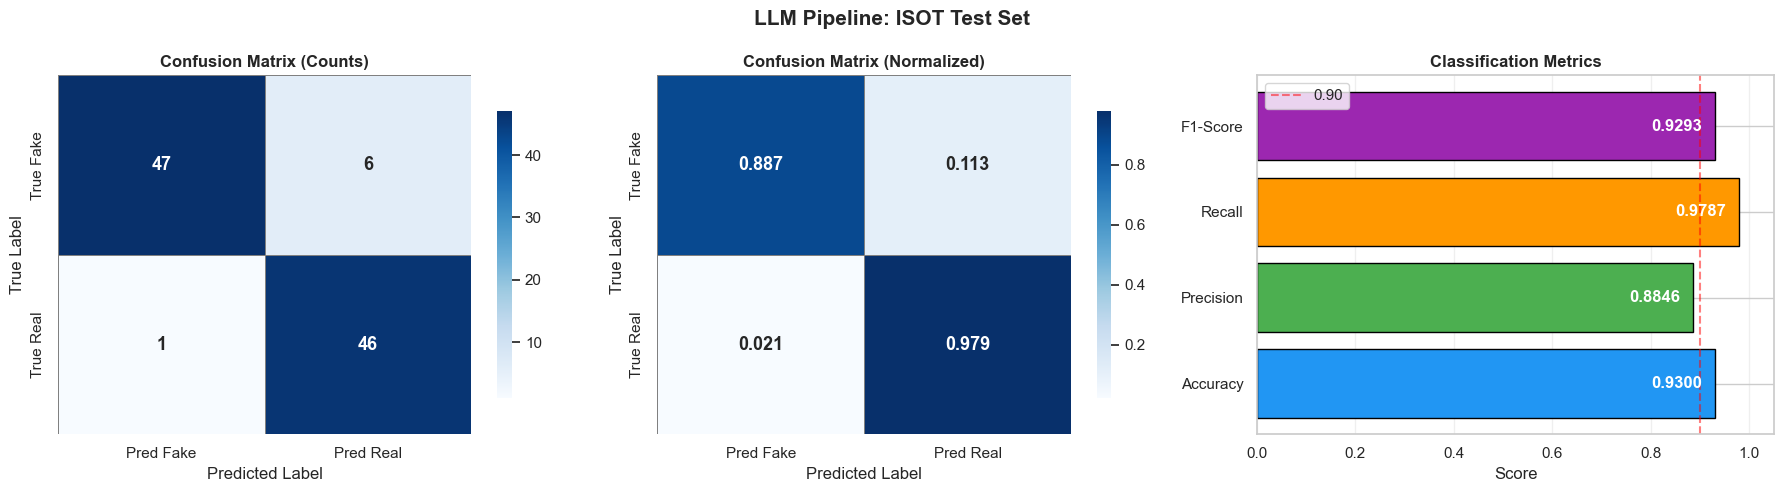

In [57]:
LABEL_TO_INT = {"TRUE": 1, "FALSE": 0}   # Real=1, Fake=0 (same as BERT)

with open(Config.RESULTS_FILE, encoding="utf-8") as f:   # load saved results
    _data = json.load(f)
_results, _summary = _data["results"], _data["summary"]

y_true, y_pred = [], []               # build label arrays from classifier verdicts
for r in _results:
    if "error" in r:                  # skip errored rows
        continue
    gt = r["ground_truth"].strip().upper()
    pred = r["classifier"]["label"].strip().upper()
    if gt in LABEL_TO_INT and pred in LABEL_TO_INT:
        y_true.append(LABEL_TO_INT[gt]); y_pred.append(LABEL_TO_INT[pred])

print(f"Evaluating {len(y_true)} classified articles "
      f"(Real={sum(y_true)}, Fake={len(y_true) - sum(y_true)})")

acc  = accuracy_score(y_true, y_pred)                                  # objective metrics
prec = precision_score(y_true, y_pred, average="binary", zero_division=0)
rec  = recall_score(y_true, y_pred, average="binary", zero_division=0)
f1   = f1_score(y_true, y_pred, average="binary", zero_division=0)
cm   = confusion_matrix(y_true, y_pred, labels=[0, 1])                 # [[TN,FP],[FN,TP]]

metrics_table = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
                              "Score": [acc, prec, rec, f1]})
print(); print(metrics_table.to_string(index=False, float_format="{:.4f}".format)); print()
print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["Fake", "Real"], zero_division=0))
print(f"Confusion: TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))                        # 3 panels
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True).clip(min=1)   # row-normalized
for ax, data, fmt, title in [(axes[0], cm, "d", "Counts"), (axes[1], cm_norm, ".3f", "Normalized")]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", ax=ax,        # confusion-matrix heatmaps
                xticklabels=["Pred Fake", "Pred Real"], yticklabels=["True Fake", "True Real"],
                linewidths=0.5, linecolor="gray", cbar_kws={"shrink": 0.8},
                annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(f"Confusion Matrix ({title})", fontweight="bold")
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
ax = axes[2]                          # metrics bar chart
names, vals = ["Accuracy", "Precision", "Recall", "F1-Score"], [acc, prec, rec, f1]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
bars = ax.barh(names, vals, color=colors, edgecolor="black")
for bar, v in zip(bars, vals):        # value labels
    ax.text(v - 0.025, bar.get_y() + bar.get_height() / 2, f"{v:.4f}",
            va="center", ha="right", fontweight="bold", color="white", fontsize=12)
ax.set_xlim([0, 1.05]); ax.axvline(0.9, color="red", linestyle="--", alpha=0.5, label="0.90")  # 0.90 ref line
ax.set_title("Classification Metrics", fontweight="bold"); ax.set_xlabel("Score"); ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.suptitle("LLM Pipeline: ISOT Test Set", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig("llm_objective_metrics.png", dpi=150, bbox_inches="tight"); plt.show()


Judge agreement rate : 0.534 (over 73 judged)
RAGAS mean scores    : {'faithfulness': 0.886, 'answer_relevancy': 0.46, 'context_precision': 0.408, 'context_recall': 0.45, 'answer_correctness': 0.737}


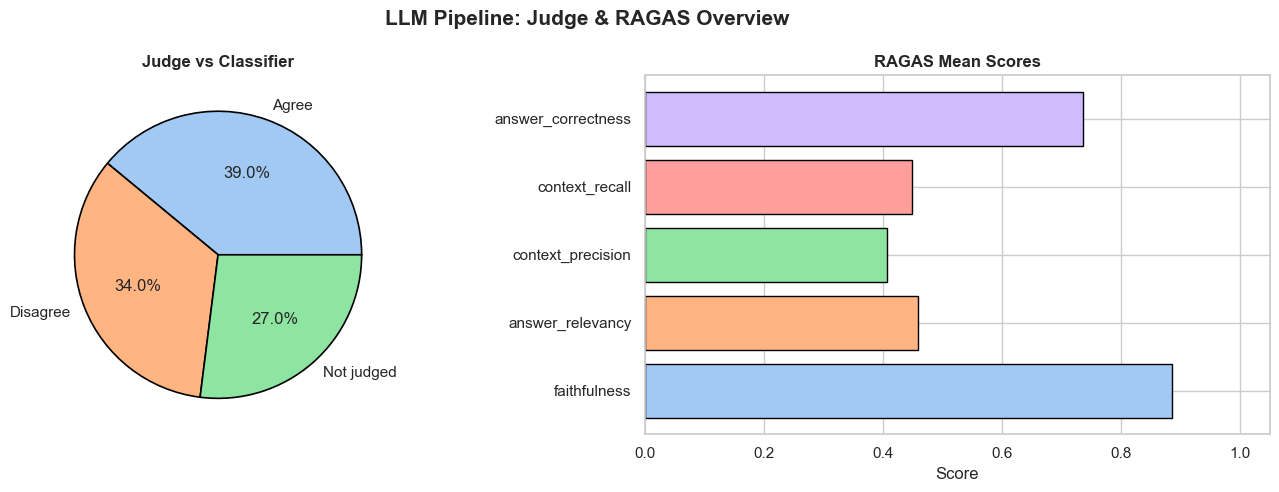

In [58]:
# Evaluation B: RAGAS-based diagnostic over the RAGAS subset (RAGAS means); judge agreement (Gemini)
judged   = [r for r in _results if r.get("judge_agrees_with_classifier") is not None]   # judged rows
agree    = sum(r["judge_agrees_with_classifier"] for r in judged)
disagree = len(judged) - agree
blocked  = sum(1 for r in _results if "error" not in r and r.get("judge_agrees_with_classifier") is None)  # filtered
print(f"Judge agreement rate : {_summary.get('judge_agreement_rate')} (over {_summary.get('n_judged')} judged)")
print(f"RAGAS mean scores    : {_summary.get('ragas_mean_scores')}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie([agree, disagree, blocked], labels=["Agree", "Disagree", "Not judged"],   # judge breakdown
            autopct=lambda p: f"{p:.1f}%" if p > 0 else "", colors=sns.color_palette("pastel"),
            wedgeprops={"edgecolor": "black", "linewidth": 1.2})
axes[0].set_title("Judge vs Classifier", fontweight="bold")
means = {k: v for k, v in (_summary.get("ragas_mean_scores") or {}).items() if v is not None}   # drop None
if means:
    axes[1].barh(list(means.keys()), list(means.values()), color=sns.color_palette("pastel"), edgecolor="black")
    axes[1].set_xlim([0, 1.05]); axes[1].set_title("RAGAS Mean Scores", fontweight="bold"); axes[1].set_xlabel("Score")
plt.suptitle("LLM Pipeline: Judge & RAGAS Overview", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig("llm_judge_overview.png", dpi=150, bbox_inches="tight"); plt.show()


## Iteration evaluation and conclusion: 
some metrics improved while others fared less well. It is to be noted that flactuations may be caused by the limited sample size.

Notably recall seems higher but precision lower for the Classfier. RAGAs gave higher scores for faithfulness and answer relevancy (not a target metric as discussed), but context recall and output precision, which we hoped to improve, dropped, and the Judge LLM agreed markedly less with the Classifier than the initial (not too impressive metric). This also showcases the unpredictability of LLM output even with a low temperature, and numberous more iterations of an experimental nature -and with a larger sample, including statistical analysis of differences- will be required to realiably document the effects of out fine tuning, which we now will now not undertake due to our limited LLM/API resources. In the future, such pipelines may also be set to automnomously self-calibrate in an agentic AI framework.